# Cell 1: Markdown (Judul & Penjelasan)
# # Prediksi Suhu Maksimum (TMAX) Seattle - Perbandingan 5 Algoritma Machine Learning
# 
# Notebook ini mendemonstrasikan pelatihan dan evaluasi 5 algoritma:
# 1. Linear Regression
# 2. Artificial Neural Network (ANN)
# 3. Long Short-Term Memory (LSTM)
# 4. K-Means Clustering
# 5. Backpropagation Network (Custom Training Loop)
# 
# Dataset: Seattle Weather (1948-2017) dari Kaggle.

In [1]:
# Cell 2: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (mean_absolute_error, 
                             mean_squared_error, 
                             r2_score,
                             silhouette_score)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# Cell 3: Load Dataset & EDA
df = pd.read_csv('seattleWeather_1948-2017.csv')
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE').reset_index(drop=True)

# Convert RAIN to binary
df['RAIN'] = df['RAIN'].map({'TRUE': 1, 'FALSE': 0})
df['RAIN'] = df['RAIN'].fillna(0)

# Drop rows with missing TMAX/TMIN/PRCP
df = df.dropna(subset=['TMAX', 'TMIN', 'PRCP'])

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['DATE'].min()} to {df['DATE'].max()}")
df.head()

Dataset shape: (25548, 5)
Date range: 1948-01-01 00:00:00 to 2017-12-14 00:00:00


,DATE,PRCP,TMAX,TMIN,RAIN
0,1948-01-01,0.47,51,42,0.0
1,1948-01-02,0.59,45,36,0.0
2,1948-01-03,0.42,45,35,0.0
3,1948-01-04,0.31,45,34,0.0
4,1948-01-05,0.17,45,32,0.0


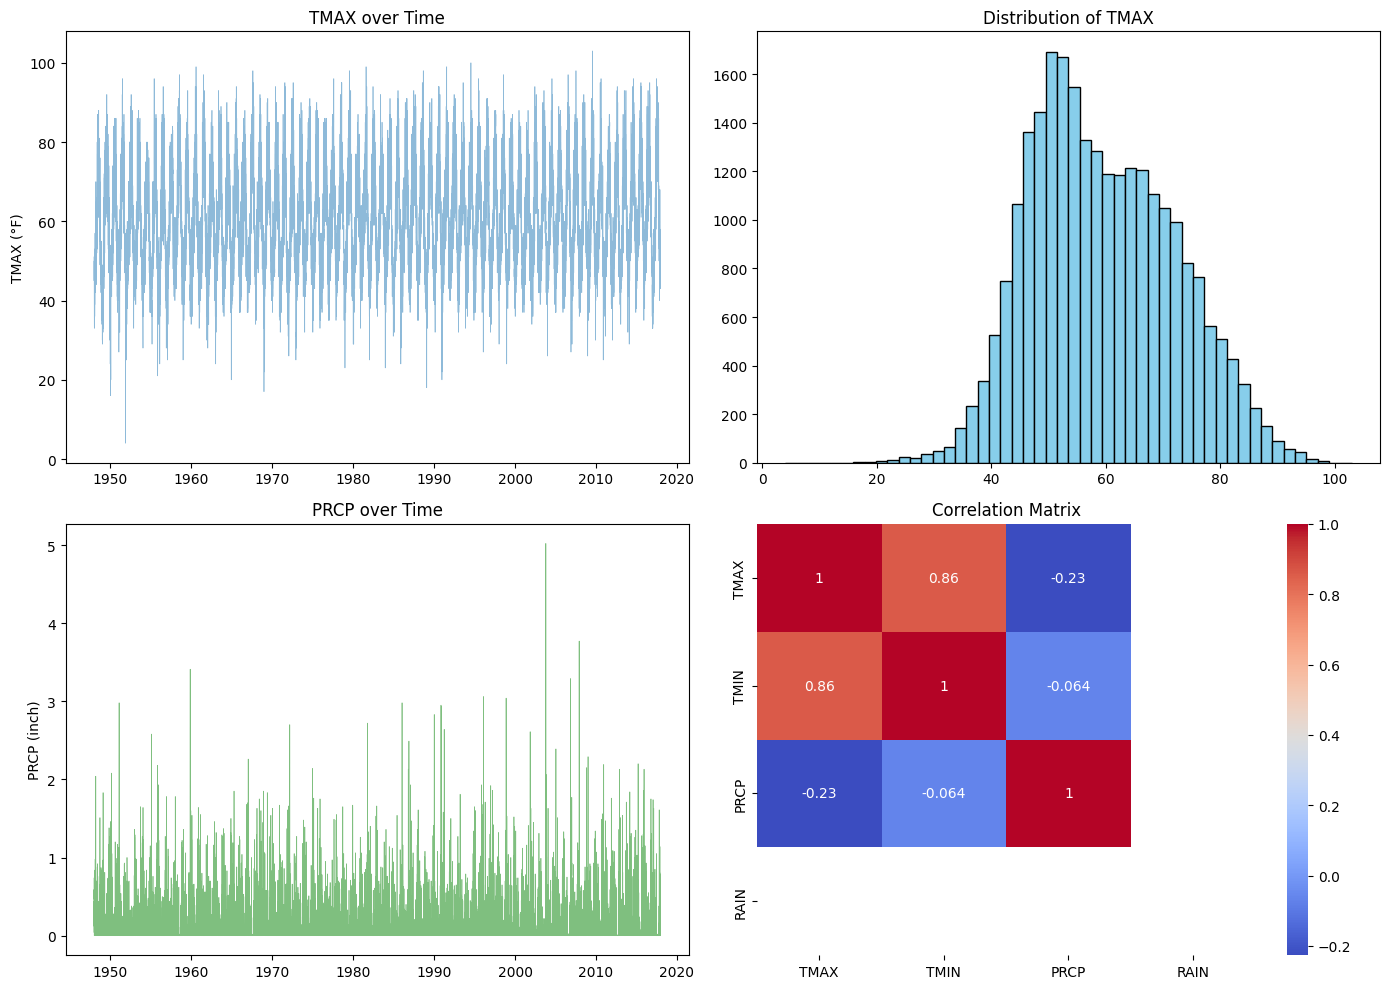

In [3]:
# Cell 4: Exploratory Data Analysis (EDA)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].plot(df['DATE'], df['TMAX'], alpha=0.5, linewidth=0.5)
axes[0,0].set_title('TMAX over Time')
axes[1,0].set_ylabel('PRCP (inch)')
axes[0,0].set_ylabel('TMAX (°F)')

axes[0,1].hist(df['TMAX'], bins=50, color='skyblue', edgecolor='black')
axes[0,1].set_title('Distribution of TMAX')

axes[1,0].plot(df['DATE'], df['PRCP'], alpha=0.5, linewidth=0.5, color='green')
axes[1,0].set_title('PRCP over Time')

corr = df[['TMAX','TMIN','PRCP','RAIN']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1,1])
axes[1,1].set_title('Correlation Matrix')

plt.tight_layout()
plt.savefig('eda_plot.png', dpi=150)
plt.show()

In [4]:
# Cell 5: Feature Engineering (Lag Features)
for lag in [1, 2, 3]:
    df[f'TMAX_lag{lag}'] = df['TMAX'].shift(lag)
    df[f'TMIN_lag{lag}'] = df['TMIN'].shift(lag)
    df[f'PRCP_lag{lag}'] = df['PRCP'].shift(lag)
    df[f'RAIN_lag{lag}'] = df['RAIN'].shift(lag)

# Drop rows with NaN created by lags
df = df.dropna()
print(f"Shape after lag features: {df.shape}")

Shape after lag features: (25545, 17)


In [5]:
# Cell 6: Define Features and Target
feature_cols = ['TMAX_lag1','TMAX_lag2','TMAX_lag3',
                'TMIN_lag1','TMIN_lag2','TMIN_lag3',
                'PRCP_lag1','PRCP_lag2','PRCP_lag3',
                'RAIN_lag1','RAIN_lag2','RAIN_lag3',
                'TMIN','PRCP','RAIN']

X = df[feature_cols].values
y = df['TMAX'].values

# Train/test split preserving time order
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

Training samples: 20436, Testing samples: 5109


In [6]:
# Cell 7: Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling completed.")

Scaling completed.


In [7]:
# Cell 8: Define Evaluation Function
def evaluate(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name}: MAE = {mae:.2f} °F, RMSE = {rmse:.2f} °F, R² = {r2:.4f}")
    return mae, rmse, r2

results = {}

In [8]:
# Cell 9: 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

mse_lr, rmse_lr, r2_lr = evaluate(y_test, y_pred_lr, "Linear Regression")
results['Linear Regression'] = {'MAE': mse_lr, 'RMSE': rmse_lr, 'R2': r2_lr}

Linear Regression: MAE = 3.68 °F, RMSE = 4.69 °F, R² = 0.8702


160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 754us/step
ANN: MAE = 3.35 °F, RMSE = 4.30 °F, R² = 0.8910


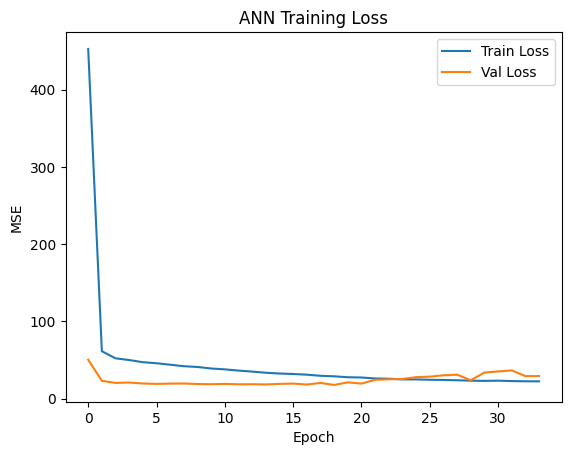

In [9]:
# Cell 10: 2. Artificial Neural Network (ANN)
ann = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])
ann.compile(optimizer='adam', loss='mse', metrics=['mae'])
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history_ann = ann.fit(X_train_scaled, y_train, epochs=100, batch_size=32,
                      validation_split=0.15, callbacks=[early_stop], verbose=0)

y_pred_ann = ann.predict(X_test_scaled).flatten()
mse_ann, rmse_ann, r2_ann = evaluate(y_test, y_pred_ann, "ANN")
results['ANN'] = {'MAE': mse_ann, 'RMSE': rmse_ann, 'R2': r2_ann}

# Plot loss curve
plt.plot(history_ann.history['loss'], label='Train Loss')
plt.plot(history_ann.history['val_loss'], label='Val Loss')
plt.title('ANN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.savefig('ann_loss.png')
plt.show()

LSTM data shapes: X_train=(20432, 3, 4), y_train=(20432,)
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
LSTM: MAE = 6.04 °F, RMSE = 7.86 °F, R² = 0.6353


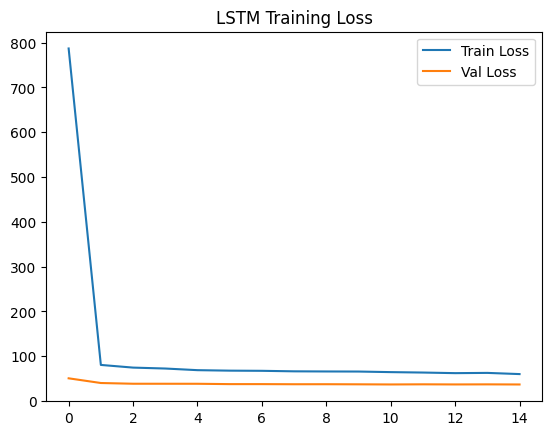

In [10]:
# Cell 11: 3. LSTM (Time Series Approach)
# Prepare sequence data for LSTM: use raw TMAX, TMIN, PRCP, RAIN as features with 3 time steps
raw_features = df[['TMAX','TMIN','PRCP','RAIN']].values
scaler_seq = StandardScaler()
raw_features_scaled = scaler_seq.fit_transform(raw_features)

def create_sequences(data, seq_length=3):
    X_seq, y_seq = [], []
    for i in range(len(data) - seq_length - 1):
        X_seq.append(data[i:i+seq_length])
        # target is TMAX at next step (original scale, not scaled)
        y_seq.append(df['TMAX'].values[i+seq_length+1])  # plus 1 because we want day after sequence
    return np.array(X_seq), np.array(y_seq)

# Note: we need to align with the same split as earlier; we'll use the same number of samples from the end
# Since we removed NaN rows, we need to rebuild sequences on the df already filtered.
# Let's rebuild on the same df (post lag feature removal). However, we'll use the df with only raw features + lags already removed.
# Simpler: use the df after lag features, but we'll take the raw TMAX,TMIN,PRCP,RAIN from that df.
df_raw_for_lstm = df[['TMAX','TMIN','PRCP','RAIN']].copy()
raw_features_for_lstm = df_raw_for_lstm.values
X_seq, y_seq = create_sequences(raw_features_for_lstm, seq_length=3)
# Now X_seq shape: (samples, 3, 4)
# Scale X_seq: reshape to 2D, scale, then reshape back
scaler_lstm = StandardScaler()
orig_shape = X_seq.shape
X_seq_reshaped = X_seq.reshape(-1, X_seq.shape[-1])
X_seq_scaled = scaler_lstm.fit_transform(X_seq_reshaped).reshape(orig_shape)

# Split train/test (80/20)
split_idx_seq = int(0.8 * len(X_seq_scaled))
X_train_seq, X_test_seq = X_seq_scaled[:split_idx_seq], X_seq_scaled[split_idx_seq:]
y_train_seq, y_test_seq = y_seq[:split_idx_seq], y_seq[split_idx_seq:]

print(f"LSTM data shapes: X_train={X_train_seq.shape}, y_train={y_train_seq.shape}")

# Build LSTM
lstm_model = models.Sequential([
    layers.LSTM(64, activation='tanh', return_sequences=True, input_shape=(3, 4)),
    layers.Dropout(0.2),
    layers.LSTM(32, activation='tanh'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history_lstm = lstm_model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=32,
                              validation_split=0.15, callbacks=[early_stop], verbose=0)

y_pred_lstm = lstm_model.predict(X_test_seq).flatten()
mse_lstm, rmse_lstm, r2_lstm = evaluate(y_test_seq, y_pred_lstm, "LSTM")
results['LSTM'] = {'MAE': mse_lstm, 'RMSE': rmse_lstm, 'R2': r2_lstm}

plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('LSTM Training Loss')
plt.legend()
plt.savefig('lstm_loss.png')
plt.show()

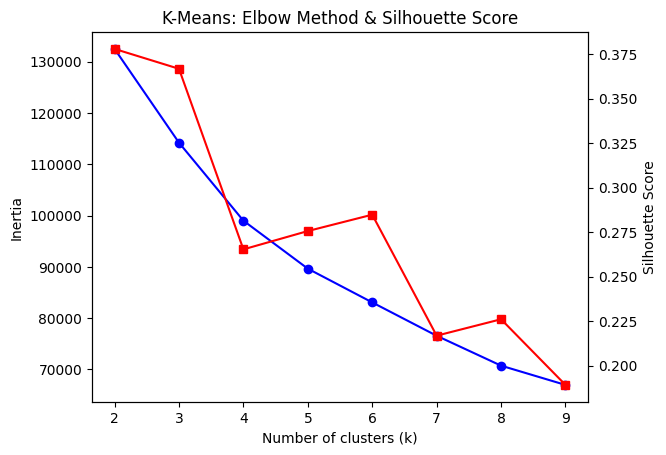

Best Silhouette Score: 0.378 at k=2


In [11]:
# Cell 12: 4. K-Means Clustering
kmeans_data = X_train_scaled.copy()
inertias = []
silhouette_scores = []
K_range = range(2, 10)
best_score = -1
best_k = 2
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(kmeans_data)
    inertias.append(km.inertia_)
    score = silhouette_score(kmeans_data, labels)
    silhouette_scores.append(score)
    if score > best_score:
        best_score = score
        best_k = k

# Plot Elbow
fig, ax1 = plt.subplots()
ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_scores, 'rs-')
ax2.set_ylabel('Silhouette Score')
plt.title('K-Means: Elbow Method & Silhouette Score')
plt.savefig('kmeans_elbow.png')
plt.show()

print(f"Best Silhouette Score: {best_score:.3f} at k={best_k}")
results['K-Means'] = {'Best K': best_k, 'Silhouette': best_score, 'Inertia': inertias}

Epoch 1/100
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 878.0985 - mae: 22.3769 - val_loss: 101.1331 - val_mae: 7.0294
Epoch 2/100
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 56.2499 - mae: 5.7201 - val_loss: 38.6175 - val_mae: 4.3710
Epoch 3/100
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 28.8325 - mae: 4.1665 - val_loss: 24.1317 - val_mae: 3.6842
Epoch 4/100
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 23.1177 - mae: 3.7526 - val_loss: 20.8637 - val_mae: 3.5263
Epoch 5/100
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 21.6844 - mae: 3.6309 - val_loss: 19.7668 - val_mae: 3.4530
Epoch 6/100
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 21.1795 - mae: 3.5846 - val_loss: 19.1437 - val_mae: 3.3982
Epoch 7/100
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 20.9196 - mae: 3.5600 - val_loss: 18.8279 - val_mae: 3.3661
Epoch 8/100
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 20.7310 - mae: 3.5412 - val_loss: 18.6222 - val_mae: 3.3446
Epoch 9/100
543/543 ━━━━━━━━━

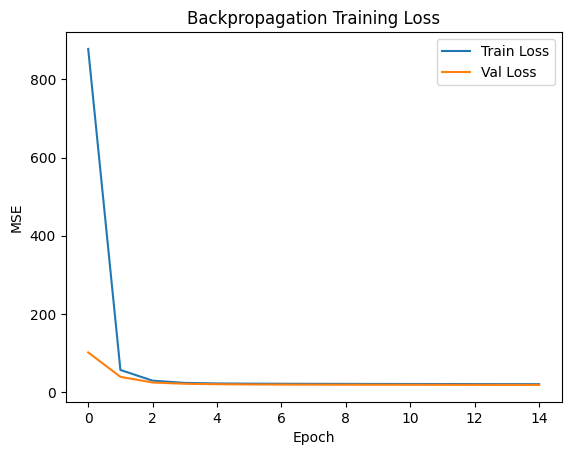

In [12]:
# Cell 13: 5. Backpropagation Model (Custom Training Loop)
class BackpropModel(keras.Model):
    def __init__(self):
        super().__init__()
        self.dense1 = layers.Dense(64, activation='relu')
        self.dense2 = layers.Dense(32, activation='relu')
        self.out = layers.Dense(1)

    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        return self.out(x)

# Inisialisasi model
bp_model = BackpropModel()

# Compile model dengan optimizer dan loss
bp_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early stopping (pakai yang sudah didefinisikan di Cell 10)
# early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Latih model (pakai .fit() biasa karena custom train_step/test_step sudah otomatis ditangani oleh Keras)
history_bp = bp_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

# Prediksi
y_pred_bp = bp_model.predict(X_test_scaled).flatten()

# Evaluasi
mse_bp, rmse_bp, r2_bp = evaluate(y_test, y_pred_bp, "Backpropagation")
results['Backpropagation'] = {'MAE': mse_bp, 'RMSE': rmse_bp, 'R2': r2_bp}

# Plot loss curve
plt.plot(history_bp.history['loss'], label='Train Loss')
plt.plot(history_bp.history['val_loss'], label='Val Loss')
plt.title('Backpropagation Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.savefig('bp_loss.png')
plt.show()

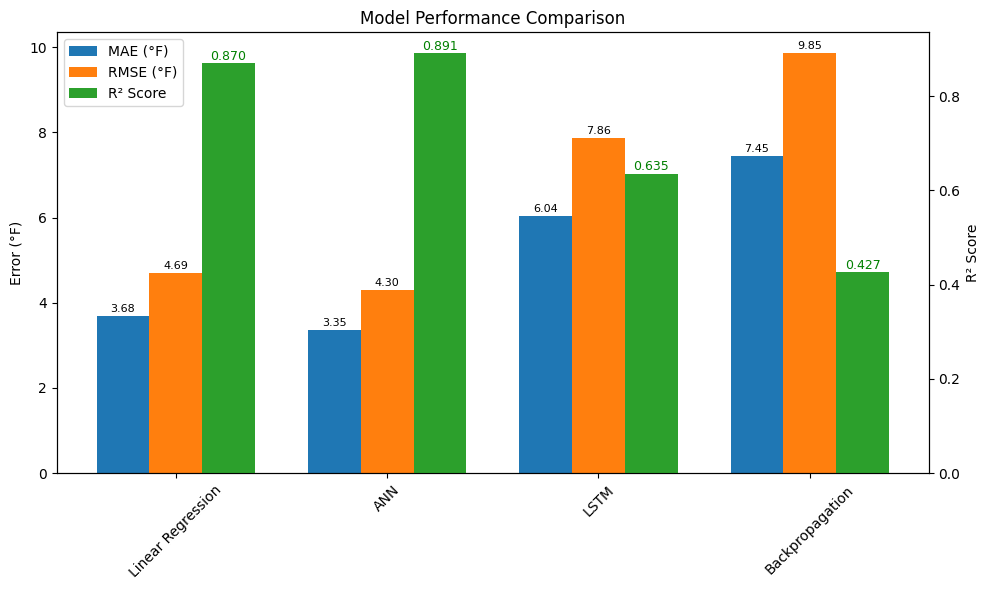

In [13]:
# Cell 14: Visualisasi Perbandingan Regresi
import matplotlib.pyplot as plt
import numpy as np

# Ambil hanya hasil model regresi (yang punya kunci 'MAE')
reg_results = {k: v for k, v in results.items() if 'MAE' in v}

# Urutkan model sesuai keinginan (Linear Regression, ANN, LSTM, Backpropagation)
order = ['Linear Regression', 'ANN', 'LSTM', 'Backpropagation']
models_names = [m for m in order if m in reg_results]

mae_vals = [reg_results[m]['MAE'] for m in models_names]
rmse_vals = [reg_results[m]['RMSE'] for m in models_names]
r2_vals = [reg_results[m]['R2'] for m in models_names]

x = np.arange(len(models_names))
width = 0.25

fig, ax1 = plt.subplots(figsize=(10,6))
bars1 = ax1.bar(x - width, mae_vals, width, label='MAE (°F)', color='#1f77b4')
bars2 = ax1.bar(x, rmse_vals, width, label='RMSE (°F)', color='#ff7f0e')
ax1.set_ylabel('Error (°F)')
ax1.set_xticks(x)
ax1.set_xticklabels(models_names, rotation=45)

ax2 = ax1.twinx()
bars3 = ax2.bar(x + width, r2_vals, width, label='R² Score', color='#2ca02c')
ax2.set_ylabel('R² Score')

# Tambahkan label nilai di atas setiap batang
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.05, f'{height:.2f}',
             ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.05, f'{height:.2f}',
             ha='center', va='bottom', fontsize=8)
for bar in bars3:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.001, f'{height:.3f}',
             ha='center', va='bottom', fontsize=9, color='green')

# Gabungkan legenda dari kedua sumbu
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Model Performance Comparison')
plt.tight_layout()
plt.savefig('comparison_bar.png', dpi=150)
plt.show()

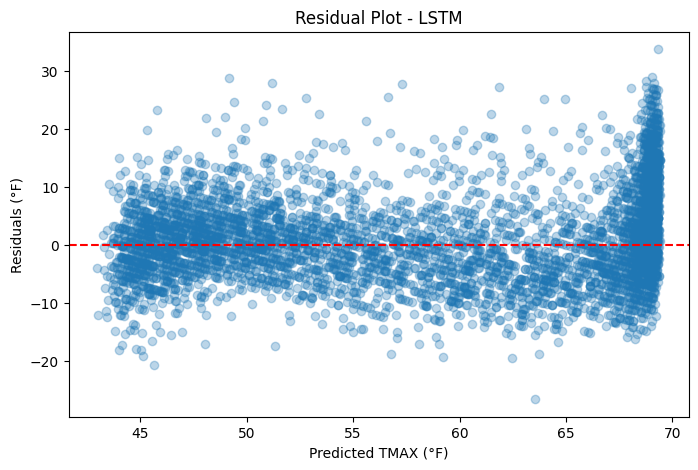

In [14]:
# Cell 15: Residual Plot untuk model terbaik (pilih LSTM misalnya)
best_y_true = y_test_seq  # LSTM target
best_y_pred = y_pred_lstm
residuals = best_y_true - best_y_pred
plt.figure(figsize=(8,5))
plt.scatter(best_y_pred, residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted TMAX (°F)')
plt.ylabel('Residuals (°F)')
plt.title('Residual Plot - LSTM')
plt.savefig('residuals_lstm.png', dpi=150)
plt.show()

In [15]:
# Cell 16: Tabel Perbandingan Akhir (Markdown)
from IPython.display import Markdown

table = "| Model | MAE (°F) | RMSE (°F) | R² Score |\n"
table += "|-------|----------|-----------|----------|\n"
for model, met in reg_results.items():
    table += f"| {model} | {met['MAE']:.2f} | {met['RMSE']:.2f} | {met['R2']:.4f} |\n"
if 'K-Means' in results:
    table += f"\n**K-Means**: Best k = {results['K-Means']['Best K']}, Silhouette Score = {results['K-Means']['Silhouette']:.4f}\n"
Markdown(table)

| Model | MAE (°F) | RMSE (°F) | R² Score |
|-------|----------|-----------|----------|
| Linear Regression | 3.68 | 4.69 | 0.8702 |
| ANN | 3.35 | 4.30 | 0.8910 |
| LSTM | 6.04 | 7.86 | 0.6353 |
| Backpropagation | 7.45 | 9.85 | 0.4268 |

**K-Means**: Best k = 2, Silhouette Score = 0.3779


In [16]:
# Cell 17: (Opsional) Simpan semua model dan hasil
import joblib
joblib.dump(lr, 'linear_regression.pkl')
joblib.dump(scaler, 'scaler.pkl')
ann.save('ann_model.h5')
lstm_model.save('lstm_model.h5')
bp_model.save('backprop_model.h5')
joblib.dump(KMeans(n_clusters=best_k, random_state=42, n_init=10).fit(X_train_scaled), 'kmeans.pkl')
import json
with open('results.json', 'w') as f:
    json.dump({k: (v.tolist() if isinstance(v, np.ndarray) else v) for k, v in results.items()}, f, indent=4)
print("All models and results saved.")

All models and results saved.
